In [2]:
import pandas as pd

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
train.shape
train.info()
train.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [4]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.10.0+cpu
False


In [5]:
train["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

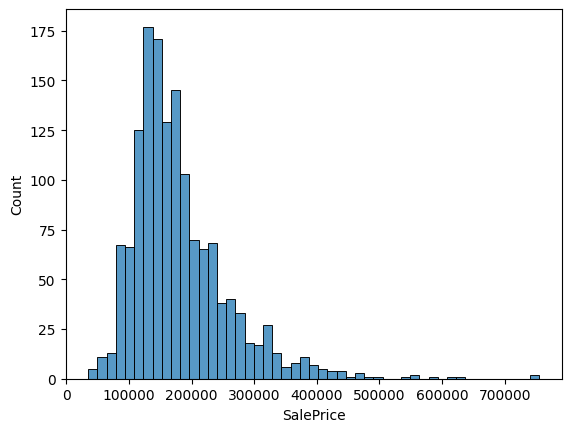

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(train["SalePrice"])
plt.show()


In [7]:
train.isnull().sum().sort_values(ascending=False).head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
dtype: int64

In [8]:
train.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False).head(10)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

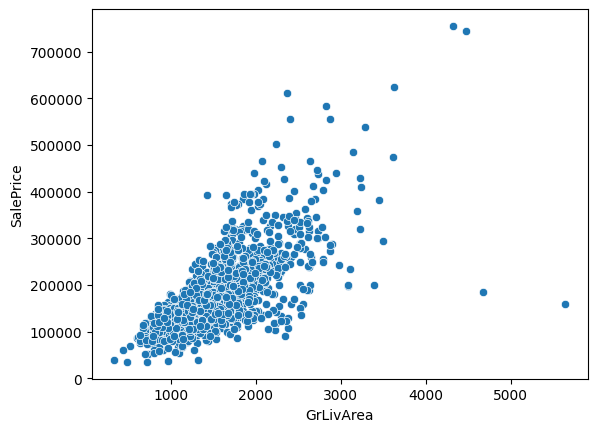

In [9]:
sns.scatterplot(x=train["GrLivArea"],y=train["SalePrice"])
plt.show()

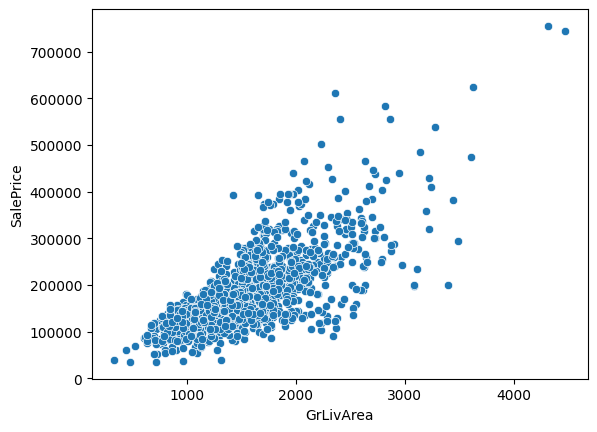

In [10]:
train = train.drop(train[(train["SalePrice"] < 300000) & (train["GrLivArea"]> 4000)].index)
sns.scatterplot(x=train["GrLivArea"],y=train["SalePrice"])
plt.show()

In [11]:
import numpy as np
train["SalePrice"] = np.log1p(train["SalePrice"])

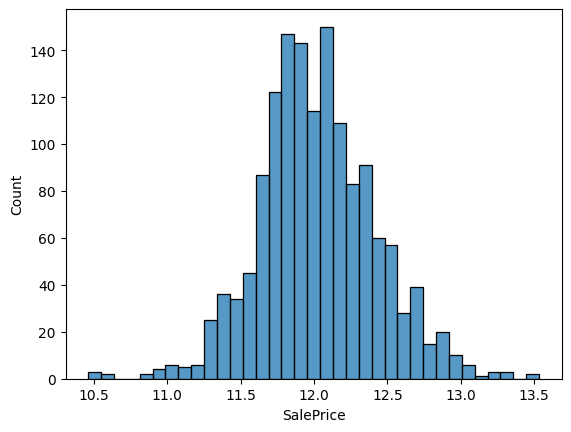

In [12]:
sns.histplot(train["SalePrice"])
plt.show()

In [13]:
missing = train.isnull().sum().sort_values(ascending=False)
missing[missing > 0].head()

PoolQC         1452
MiscFeature    1404
Alley          1367
Fence          1177
MasVnrType      872
dtype: int64

In [14]:
train["MasVnrType"] = train["MasVnrType"].fillna("None")
train["MasVnrArea"] = train["MasVnrType"].fillna("0")

In [15]:
missing = train.isnull().sum().sort_values(ascending=False)
missing[missing > 0].head()

PoolQC         1452
MiscFeature    1404
Alley          1367
Fence          1177
FireplaceQu     690
dtype: int64

In [16]:
train.select_dtypes(include=["object","string"]).columns
train.select_dtypes(include=["object","string"]).shape

(1458, 44)

In [17]:
# 결측치 처리 LotFrontage는 동네별로 비슷한 경향 그래서 Neighborhood랑 묶어서 Neighborhood기준 median으로 transform
# LotFrontage는 집과 집앞도로와의 거리
train["LotFrontage"] = train.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x : x.fillna(x.median())
    )

In [18]:
# 시설형 feature들 결측치는 보통 없는경우가 많아 none처리

none_cols = [
    "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "MasVnrType"
]

for col in none_cols:
    train[col] = train[col].fillna("None")

In [19]:
# 수치형 결측치들은 보통 시설이없으면 0 처리

zero_cols = [
    "MasVnrArea", "GarageYrBlt", "GarageArea", "GarageCars",
    "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF",
    "BsmtFullBath", "BsmtHalfBath"
]

for col in zero_cols:
    train[col] = train[col].fillna(0)

In [20]:
missing = train.isnull().sum().sort_values(ascending=False)
missing[missing > 0].head(20)

Electrical    1
dtype: int64

In [21]:
train[["SalePrice","OverallQual","GrLivArea","GarageCars","TotalBsmtSF"]].corr()

,SalePrice,OverallQual,GrLivArea,GarageCars,TotalBsmtSF
SalePrice,1.000000,0.821405,0.725211,0.681033,0.647563
OverallQual,0.821405,1.000000,0.589414,0.600741,0.538595
GrLivArea,0.725211,0.589414,1.000000,0.475442,0.408793
GarageCars,0.681033,0.600741,0.475442,1.000000,0.451890
TotalBsmtSF,0.647563,0.538595,0.408793,0.451890,1.000000


In [22]:
train["Electrical"] = train["Electrical"].fillna(train["Electrical"].mode()[0])

In [23]:
train.isnull().sum().sort_values(ascending=False).head(20)

Id              0
MSSubClass      0
MSZoning        0
LotFrontage     0
LotArea         0
Street          0
Alley           0
LotShape        0
LandContour     0
Utilities       0
LotConfig       0
LandSlope       0
Neighborhood    0
Condition1      0
Condition2      0
BldgType        0
HouseStyle      0
OverallQual     0
OverallCond     0
YearBuilt       0
dtype: int64

In [24]:
train = train.drop("Id", axis=1)
test = test.drop("Id",axis=1)

In [25]:
train = pd.get_dummies(train)
test = pd.get_dummies(test)

In [26]:
train, test = train.align(test, join='left',axis=1,fill_value=0)

In [27]:
X = train.drop("SalePrice", axis=1)
y = train["SalePrice"]

In [28]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators = 200,
    random_state = 42
)
    
rf.fit(X,y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [29]:
pred = rf.predict(test)
pred = np.expm1(pred)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- SalePrice


In [ ]:
# 오류 해결
# 1. 정답 분리
y = train["SalePrice"]

# 2. train에서 정답 제거
X = train.drop("SalePrice", axis=1)

# 3. train feature와 test feature 맞추기
X, test = X.align(test, join="left", axis=1, fill_value=0)

# 4. 모델 학습
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X, y)

# 5. 예측
pred = rf.predict(test)

# 6. 로그 되돌리기
pred = np.expm1(pred)

In [ ]:
test_ids = pd.read_csv("test.csv")["Id"]

In [ ]:
submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": pred
})

In [ ]:
submission.to_csv("sub_HP.csv", index=False)

In [ ]:
submission.head()

,Id,SalePrice
0,1461,127325.751360
1,1462,153644.534093
2,1463,178846.925341
3,1464,180421.994181
4,1465,193988.809163


In [ ]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(15)

OverallQual     0.545524
GrLivArea       0.115660
TotalBsmtSF     0.047710
GarageCars      0.036839
GarageArea      0.028926
BsmtFinSF1      0.022279
1stFlrSF        0.020657
YearBuilt       0.018104
OverallCond     0.012582
LotArea         0.011762
YearRemodAdd    0.008832
GarageYrBlt     0.007175
LotFrontage     0.006304
CentralAir_N    0.005873
BsmtUnfSF       0.005409
dtype: float64

In [ ]:
train["TotalSF"] = (
    train["TotalBsmtSF"] +
    train["1stFlrSF"] +
    train["2ndFlrSF"]
)

test["TotalSF"] = (
    test["TotalBsmtSF"] +
    test["1stFlrSF"] +
    test["2ndFlrSF"]
)

train["TotalBathrooms"] = (
    train["FullBath"] +
    train["HalfBath"] * 0.5 +
    train["BsmtFullBath"] +
    train["BsmtHalfBath"] * 0.5
)

test["TotalBathrooms"] = (
    test["FullBath"] +
    test["HalfBath"] * 0.5 +
    test["BsmtFullBath"] +
    test["BsmtHalfBath"] * 0.5
)

train["HouseAge"] = train["YrSold"] - train["YearBuilt"]
test["HouseAge"] = test["YrSold"] - train["YearBuilt"]

In [ ]:
skew_feature = train.select_dtypes(include=["int64","float64"]).columns

skew = train[skew_feature].skew().sort_values(ascending=False)
skew = skew[abs(skew) > 0.75]

skew.index

Index(['MiscVal', 'PoolArea', 'LotArea', '3SsnPorch', 'LowQualFinSF',
       'KitchenAbvGr', 'BsmtFinSF2', 'ScreenPorch', 'BsmtHalfBath',
       'EnclosedPorch', 'OpenPorchSF', 'LotFrontage', 'WoodDeckSF',
       'MSSubClass', 'GrLivArea', 'BsmtUnfSF', '1stFlrSF', '2ndFlrSF',
       'TotalSF', 'BsmtFinSF1', 'GarageYrBlt'],
      dtype='str')

In [ ]:
for col in skew.index:
    train[col] = np.log1p(train[col])
    test[col] = np.log1p(test[col])

In [ ]:
rf = RandomForestRegressor(
    n_estimators= 300,
    random_state= 42
)

rf.fit(X,y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [ ]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values(ascending=False).head(15)

OverallQual     0.548022
GrLivArea       0.114479
TotalBsmtSF     0.047573
GarageCars      0.036398
GarageArea      0.029179
BsmtFinSF1      0.022484
1stFlrSF        0.020711
YearBuilt       0.015967
OverallCond     0.012402
LotArea         0.011572
YearRemodAdd    0.008669
GarageYrBlt     0.007873
CentralAir_N    0.006349
LotFrontage     0.006202
BsmtUnfSF       0.005393
dtype: float64

In [ ]:
train["TotalSF"]
train["TotalBathrooms"]
train["HouseAge"]

0        5
1       31
2        7
3       91
4        8
        ..
1455     8
1456    32
1457    69
1458    60
1459    43
Name: HouseAge, Length: 1458, dtype: int64

In [ ]:
X = train.drop("SalePrice",axis=1)

rf.fit(X,y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [ ]:
print(X.shape)

(1458, 307)


In [ ]:
importance.sort_values(ascending=False).head(50)

OverallQual              0.548022
GrLivArea                0.114479
TotalBsmtSF              0.047573
GarageCars               0.036398
GarageArea               0.029179
BsmtFinSF1               0.022484
1stFlrSF                 0.020711
YearBuilt                0.015967
OverallCond              0.012402
LotArea                  0.011572
YearRemodAdd             0.008669
GarageYrBlt              0.007873
CentralAir_N             0.006349
LotFrontage              0.006202
BsmtUnfSF                0.005393
CentralAir_Y             0.004977
2ndFlrSF                 0.004677
MSZoning_RM              0.004308
OpenPorchSF              0.003612
GarageType_Detchd        0.003370
MSZoning_C (all)         0.003183
TotRmsAbvGrd             0.002989
MoSold                   0.002933
GarageType_Attchd        0.002765
WoodDeckSF               0.002729
FireplaceQu_None         0.002334
Fireplaces               0.002298
MSSubClass               0.001926
BsmtQual_Gd              0.001917
KitchenAbvGr  

In [ ]:
print("TotalSF" in X.columns)
print("TotalBathrooms" in X.columns)
print("HouseAge" in X.columns)

True
True
True


In [ ]:
importance.sort_values(ascending=False)["TotalSF"]
importance.sort_values(ascending=False)["TotalBathrooms"]
importance.sort_values(ascending=False)["HouseAge"]

KeyError: 'TotalSF'

In [ ]:
X[["TotalSF","TotalBathrooms","HouseAge"]].head()

,TotalSF,TotalBathrooms,HouseAge
0,7.850493,3.5,5
1,7.833996,2.5,31
2,7.903596,3.5,7
3,7.813592,2.0,91
4,8.114923,3.5,8


In [ ]:
print("TotalSF" in importance.index)
print("TotalBathrooms" in importance.index)
print("HouseAge" in importance.index)

False
False
False


In [ ]:
y = train["SalePrice"]
X = train.drop(["SalePrice"],axis=1)

X, test = X.align(test, join="left", fill_value=0, axis=1)

rf = RandomForestRegressor(
    n_estimators = 300,
    random_state = 42
)

rf.fit(X,y)

importance = pd.Series(
    rf.feature_importances_, index = X.columns
)

print("TotalSF" in importance.index)
print("TotalBathrooms" in importance.index)
print("HouseAge" in importance.index)

True
True
True


In [ ]:
print(importance["TotalSF"])
print(importance["TotalBathrooms"])
print(importance["HouseAge"])

0.31866457359910166
0.010465490892634991
0.007219778574021971


In [ ]:
importance.sort_values(ascending=False).head(20)

OverallQual         0.446173
TotalSF             0.318665
GrLivArea           0.012321
GarageCars          0.012015
GarageArea          0.010497
TotalBathrooms      0.010465
LotArea             0.010432
CentralAir_Y        0.010232
BsmtFinSF1          0.010032
YearRemodAdd        0.009710
OverallCond         0.009492
CentralAir_N        0.008280
HouseAge            0.007220
GarageYrBlt         0.007098
BsmtUnfSF           0.006896
1stFlrSF            0.006455
YearBuilt           0.005633
LotFrontage         0.005179
TotalBsmtSF         0.004479
MSZoning_C (all)    0.003578
dtype: float64

In [ ]:
rf.score(X,y)

0.9846957002064495

In [30]:
skew = train.select_dtypes(include=["int64","float64"]).skew()
skew = skew[abs(skew)>0.75]

print(skew.sort_values(ascending=False).head(10))

MiscVal          24.460085
PoolArea         15.948945
LotArea          12.573925
3SsnPorch        10.297106
LowQualFinSF      9.004955
KitchenAbvGr      4.484883
BsmtFinSF2        4.251925
ScreenPorch       4.118929
BsmtHalfBath      4.100114
EnclosedPorch     3.087164
dtype: float64


In [31]:
import numpy as np

for col in skew.index:
    train[col] = np.log1p(train[col])
    test[col] = np.log1p(test[col])

In [32]:
y = train["SalePrice"]
X = train.drop("SalePrice",axis=1)

X, test = X.align(test, join= "left", axis = 1, fill_value= 0)

rf.fit(X,y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [33]:
from sklearn.model_selection import cross_val_score
import numpy as np

scores = cross_val_score(
    rf,
    X,
    y,
    cv = 5,
    scoring="neg_root_mean_squared_error"
)

rmse_scores = -scores

print("RMSE:",rmse_scores)
print("평균:", rmse_scores.mean())


RMSE: [0.13744444 0.1387156  0.14607323 0.12960719 0.13801256]
평균: 0.13797060042083126
